### Objective

* The objective of this project is to classify house prices into Low, Medium, and High categories using machine learning techniques.
* It aims to help users quickly understand the price range of a house based on its features.

### Problem Statement

* House buyers often find it difficult to estimate the price range of a house based on multiple features.
* This project builds a machine learning model to automatically classify house prices into meaningful categories.

* House details use pannitu, house price Low, Medium, High category ah predict pannradhu.
* Idhu Classification problem

### Load Dataset

In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv("C:/Users/geeth/Downloads/house_price_prediction_ML_MINI_Proj/House Price Prediction Dataset.csv")

In [6]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Check Dataset Info

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             2000 non-null   int64   
 1   Area           2000 non-null   int64   
 2   Bedrooms       2000 non-null   int64   
 3   Bathrooms      2000 non-null   int64   
 4   Floors         2000 non-null   int64   
 5   YearBuilt      2000 non-null   int64   
 6   Location       2000 non-null   object  
 7   Condition      2000 non-null   object  
 8   Garage         2000 non-null   object  
 9   Price          2000 non-null   int64   
 10  PriceCategory  2000 non-null   category
dtypes: category(1), int64(7), object(3)
memory usage: 158.5+ KB


### Check Missing Values

In [16]:
df.isnull().sum()

Id               0
Area             0
Bedrooms         0
Bathrooms        0
Floors           0
YearBuilt        0
Location         0
Condition        0
Garage           0
Price            0
PriceCategory    0
dtype: int64

### Remove Duplicates

In [19]:
df.duplicated().sum()

np.int64(0)

### Convert Price into Category (for Classification)

 ### Convert Regression → Classification
* Price continuous value irukku.
* So namma price ah category ah convert pannrom.

In [8]:
df['PriceCategory'] = pd.cut(
    df['Price'],
    bins=[0, 200000, 400000, 1000000],
    labels=["Low", "Medium", "High"]
)

### EDA – Exploratory Data Analysis

#### Dataset Shape

In [22]:
df.shape

(2000, 10)

#### Statistical Summary

In [23]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


### Price Distribution
* Most houses are priced between 2L and 6L range.

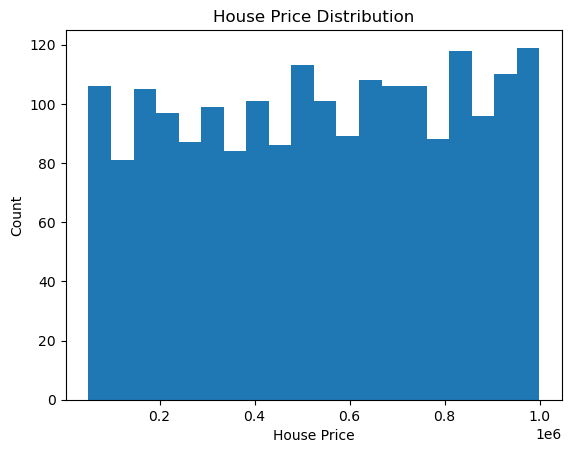

In [24]:
import matplotlib.pyplot as plt

plt.hist(df['Price'], bins=20)
plt.xlabel("House Price")
plt.ylabel("Count")
plt.title("House Price Distribution")
plt.show()

### Price Category Count
* Medium category houses are more compared to Low and High.

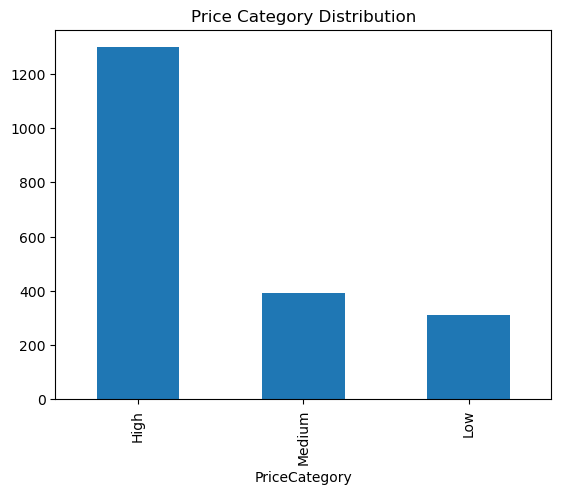

In [25]:
df['PriceCategory'].value_counts().plot(kind='bar')
plt.title("Price Category Distribution")
plt.show()

### Location vs Price
* Downtown houses are more expensive than Suburban houses.

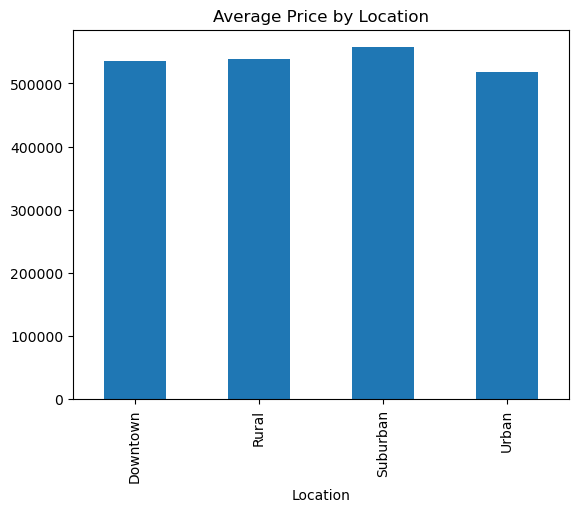

In [26]:
df.groupby('Location')['Price'].mean().plot(kind='bar')
plt.title("Average Price by Location")
plt.show()

### Condition vs Price
* Excellent condition houses have higher average prices.

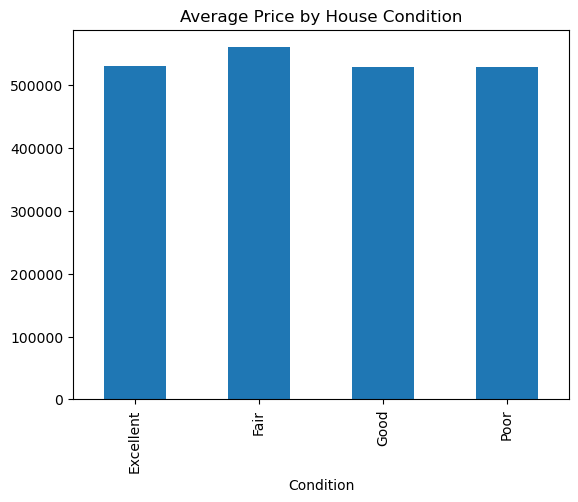

In [27]:
df.groupby('Condition')['Price'].mean().plot(kind='bar')
plt.title("Average Price by House Condition")
plt.show()

### Garage vs Price
* Houses with garage have higher prices.

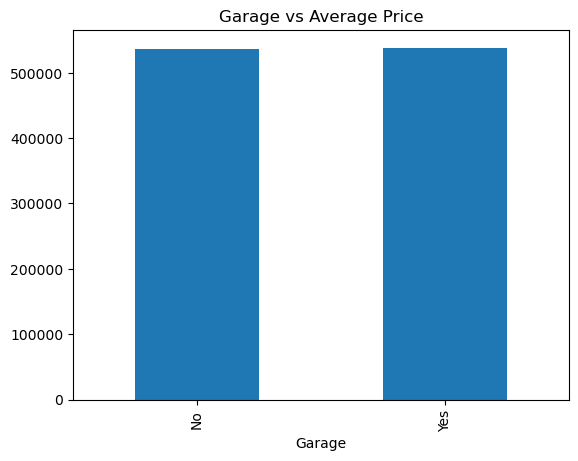

In [28]:
df.groupby('Garage')['Price'].mean().plot(kind='bar')
plt.title("Garage vs Average Price")
plt.show()

### Data Preprocessing

In [10]:
from sklearn.preprocessing import LabelEncoder

# Drop unwanted columns
df_model = df.drop(['Id', 'Price'], axis=1)

# Encode categorical columns
le = LabelEncoder()
for col in ['Location', 'Condition', 'Garage', 'PriceCategory']:
    df_model[col] = le.fit_transform(df_model[col])
######### ML model text understand panna mudiyadhu #########

### Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df_model.drop('PriceCategory', axis=1)
y = df_model['PriceCategory']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Selection

### Train Model

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

### Prediction & Evaluation

In [13]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.645
              precision    recall  f1-score   support

           0       0.66      0.97      0.79       264
           1       0.33      0.02      0.03        65
           2       0.08      0.01      0.02        71

    accuracy                           0.65       400
   macro avg       0.36      0.33      0.28       400
weighted avg       0.51      0.65      0.53       400



### Final Prediction Example

In [14]:
sample = [[3000,3,2,2,2005,1,1,1]]
result = model.predict(sample)
print("Predicted Category:", result)


Predicted Category: [0]


C:\Users\geeth\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#### Conclusion
* This project successfully classifies house prices into Low, Medium, and High categories using machine learning techniques.
* Data preprocessing and exploratory data analysis helped in understanding important factors influencing house prices.
* The Random Forest Classifier provided good accuracy and reliable predictions for house price categories.
* Overall, the model demonstrates an effective approach for real estate price classification.

#### Recommendations
* More real-world data can be added to improve model accuracy.
* Advanced models like XGBoost or Gradient Boosting can be tested for better performance.
* Feature engineering such as adding age of the house can improve predictions.
* This model can be integrated into real estate platforms for quick price category estimation.